# 15 — Out-of-Distribution Evaluation (EDF-S)

All prior JAISP metrics are on **ECDFS tract 5063** (in-distribution). This notebook evaluates the frozen v10 stack on **EDF-S (Euclid Deep Field South, tract 2394)** with **no retraining**, to test the foundation's actual value proposition: transfer to a new field.

Data: `data/edf_s_ood/` — 72 paired Euclid+Rubin tiles. **Update 2026-06-24:** the EDF-S Euclid tiles were redownloaded from ESA **with `var_*` maps** (VIS/Y/J/H) and Rubin tiles with `var`+`mask`. Both stages were re-run on the real variance (the earlier eval used a MAD-based RMS fallback because variance was missing). MAD-fallback caches are kept as `*_MADvar_backup.*` for comparison.

**What changed going from MAD→real var (both stages):**
- **Detection:** mean 456→**332 det/tile** (MAD inflated counts ~37%, mostly spurious detections in high-noise regions). Apples-to-apples vs ECDFS (413/tile, real var), EDF-S detects **~20% fewer** — it is a shallower/harder field, not a denser one as the MAD cache suggested.
- **Astrometry:** real var is a re-weighting of the joint-canonical fit (Rubin optical −3–8 mas, NISP +4–9 mas; confirmed instrument-independent via an ECDFS no-var control). Residual EDF-S vs ECDFS gap (both real var): optical +11–18 mas, NISP +4–6 mas.
- **Coherent story:** both stages agree EDF-S is a modest, uniform step harder than ECDFS; the prior lopsided picture was the var fallback.

Pipeline (each step mirrors the ECDFS production config exactly):
1. **Detection** — CenterNet v10 export → `data/detection_labels/centernet_v10_edfs_thresh03.pt` *(real var)*
2. **Astrometry** — joint canonical anchors via the latent-position head *(real var)*
3. **Comparison** — cross-instrument MAE/median vs the ECDFS reference (25.4 MAE / 11.3 median)

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'io' else Path.cwd()
OOD_CACHE   = ROOT / 'data/detection_labels/centernet_v10_edfs_thresh03.pt'
ECDFS_CACHE = ROOT / 'data/detection_labels/centernet_v10_790_thresh03.pt'
EUCLID_DIR  = ROOT / 'data/edf_s_ood/euclid_tiles_edfs'
print('root:', ROOT)
print('ood cache exists:', OOD_CACHE.exists())

root: /home/shemmati/Work/Projects/JAISP
ood cache exists: True


## Step 1 — Detection on EDF-S

Export command (run once from the repo root; mirrors the production cache config — fused CenterNet, conf 0.3, NMS 7, spike-veto off, no bright-rescue):

```bash
python models/detection/run_centernet_detections.py \
    --encoder_ckpt   models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt \
    --centernet_ckpt checkpoints/centernet_v10_uncertain_synth_r2/centernet_best.pt \
    --rubin_dir      data/edf_s_ood/rubin_tiles_edfs \
    --euclid_dir     data/edf_s_ood/euclid_tiles_edfs \
    --out            data/detection_labels/centernet_v10_edfs_thresh03.pt \
    --conf_threshold 0.3 --nms_kernel 7 --spike_veto_radius 0 --spike_veto_width 0
```

In [2]:
ood = torch.load(OOD_CACHE, map_location='cpu', weights_only=False)
labels = ood['labels']
ood_n = np.array([v[0].shape[0] for v in labels.values()])
print('config:', ood['config'].get('n_errors'), 'errors,', len(labels), 'tiles')
print('det/tile: mean %.1f  median %d  min %d  max %d' % (
    ood_n.mean(), np.median(ood_n), ood_n.min(), ood_n.max()))

config: 0 errors, 72 tiles
det/tile: mean 332.4  median 336  min 199  max 469


### 1a. Overlay detections on VIS
Red circles should sit on real sources, not blank sky / noise spikes. Bright or extended objects should not be systematically missed.

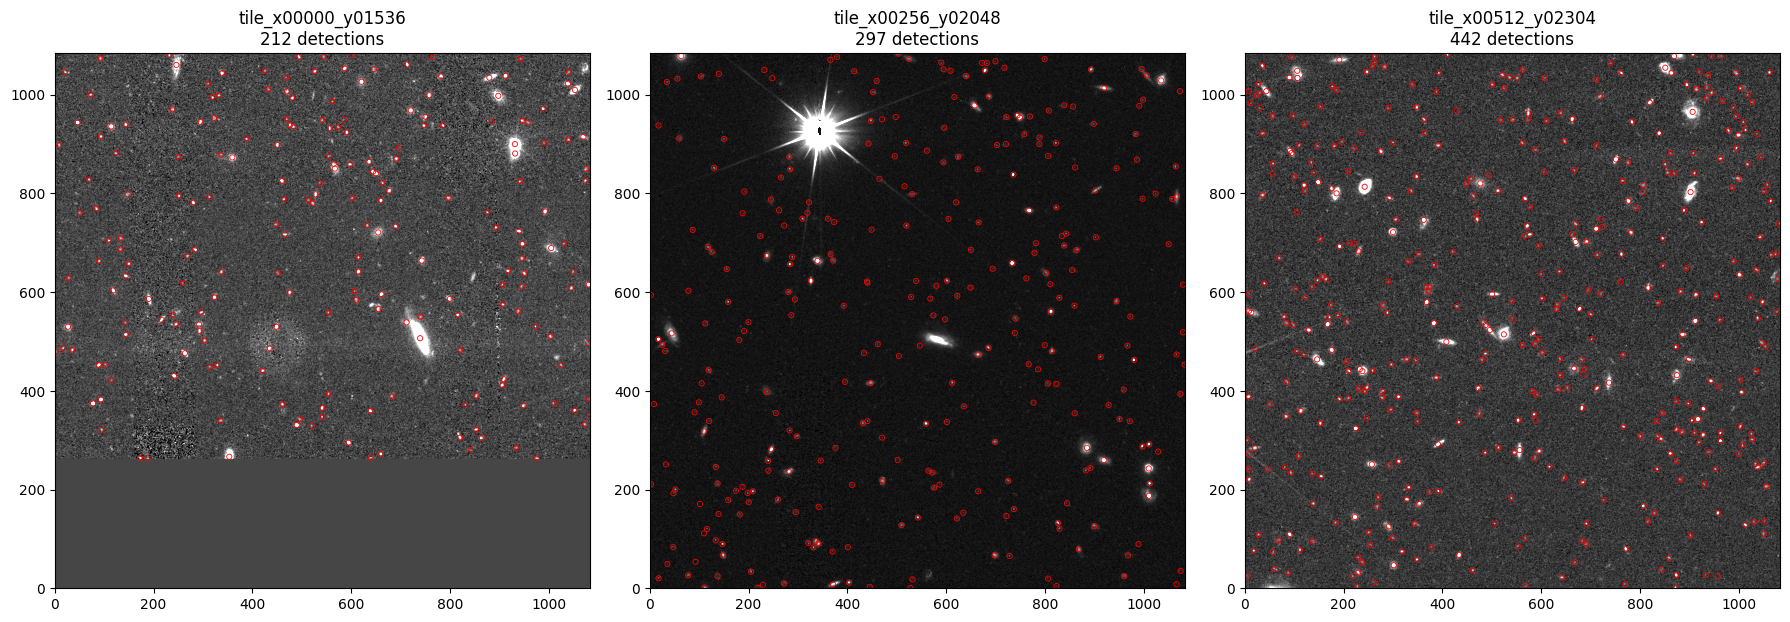

In [3]:
def zscale(img, lo=1.0, hi=99.5):
    f = img[np.isfinite(img)]
    return np.percentile(f, [lo, hi])

SHOW = ['tile_x00000_y01536', 'tile_x00256_y02048', 'tile_x00512_y02304']
show = [s for s in SHOW if s in labels] or list(labels.keys())[:3]

fig, axes = plt.subplots(1, len(show), figsize=(6 * len(show), 6))
axes = np.atleast_1d(axes)
for ax, stem in zip(axes, show):
    ed = np.load(EUCLID_DIR / f'{stem}_euclid.npz', allow_pickle=True)
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], dtype=np.float32))
    H, W = vis.shape
    vlo, vhi = zscale(vis)
    ax.imshow(vis, origin='lower', cmap='gray', vmin=vlo, vmax=vhi)
    xy, _ = labels[stem]
    ax.scatter(xy[:, 0] * W, xy[:, 1] * H, s=14, facecolors='none',
               edgecolors='red', linewidths=0.6)
    ax.set_title(f'{stem}\n{xy.shape[0]} detections')
    ax.set_xlim(0, W); ax.set_ylim(0, H)
plt.tight_layout(); plt.show()

### 1b. Detection density vs ECDFS
A uniform shift in counts/tile is expected for a deeper/denser field; a long tail driven by a few tiles flags crowding artifacts.

ECDFS det/tile: mean 413.1 median 419


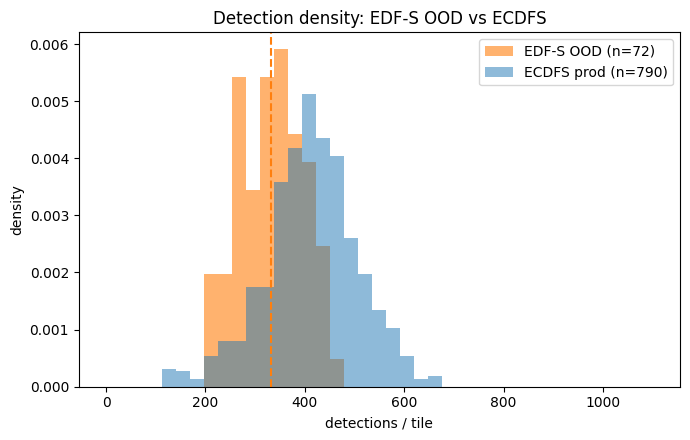

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, max(1100, ood_n.max()), 40)
ax.hist(ood_n, bins=bins, density=True, alpha=0.6, color='C1',
        label=f'EDF-S OOD (n={len(ood_n)})')
if ECDFS_CACHE.exists():
    ec = torch.load(ECDFS_CACHE, map_location='cpu', weights_only=False)
    ec_n = np.array([v[0].shape[0] for v in ec['labels'].values()])
    ax.hist(ec_n, bins=bins, density=True, alpha=0.5, color='C0',
            label=f'ECDFS prod (n={len(ec_n)})')
    print('ECDFS det/tile: mean %.1f median %d' % (ec_n.mean(), np.median(ec_n)))
ax.axvline(ood_n.mean(), color='C1', ls='--')
ax.set_xlabel('detections / tile'); ax.set_ylabel('density')
ax.set_title('Detection density: EDF-S OOD vs ECDFS'); ax.legend()
plt.tight_layout(); plt.show()

### 1c-vis. Visual overlay — what are we missing?

Before quantifying completeness, look directly. On zoomed VIS cutouts: **green rings** = MER clean sources (`vis_det & !spurious`), **blue +** = our CenterNet detections, **red rings** = MER sources with no detection within 0.5″ (the misses). Each crop is auto-centred on the densest pocket of misses (and we include the bright-star tile `tile_x00256_y02048`) so the failure modes — faint sources, blends, bright-star halos — are visible by eye.

In [ ]:
# 1c-vis. Eyeball check: MER (green) vs our detections (blue) on zoomed VIS cutouts
#   Green ring = MER clean source (vis_det & !spurious); blue + = our CenterNet detection;
#   red ring  = MER source with NO detection within 0.5" (i.e. what we are MISSING).
#   Crops are auto-centred on the densest pocket of misses so they are easy to see.
import sys
from astropy.io import fits
from astropy.wcs import WCS
from scipy.spatial import cKDTree
for _p in (str(ROOT / 'models'), str(ROOT / 'models' / 'astrometry2')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
from astrometry2.source_matching import safe_header_from_card_string

PXSCALE, RAD, CROP = 0.1, 0.5, 150   # arcsec/px, match radius arcsec, half-crop px
MER = fits.open(ROOT / 'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_TILE102021011_footprint.fits')[1].data
_clean = (np.asarray(MER['vis_det']) == 1) & (np.asarray(MER['spurious_flag']) != 1)
cRA, cDEC = np.asarray(MER['ra'], float)[_clean], np.asarray(MER['dec'], float)[_clean]

def tile_overlay(stem):
    """Return VIS image, our-det px, MER px (in-bounds), and missed-MER mask."""
    ed = np.load(EUCLID_DIR / f'{stem}_euclid.npz', allow_pickle=True)
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], dtype=np.float32))
    H, W = vis.shape
    vwcs = WCS(safe_header_from_card_string(ed['wcs_VIS'].item()))
    xy = np.asarray(labels[stem][0], float)
    ox, oy = xy[:, 0] * (W - 1), xy[:, 1] * (H - 1)
    mx, my = vwcs.all_world2pix(cRA, cDEC, 0)
    inb = (mx >= 0) & (mx < W) & (my >= 0) & (my < H)
    mx, my = mx[inb], my[inb]
    d, _ = cKDTree(np.c_[ox, oy]).query(np.c_[mx, my])
    missed = d >= RAD / PXSCALE
    return vis, ox, oy, mx, my, missed

# choose examples: the bright-star tile + the two tiles with the most missed MER sources
miss_count = {}
for stem in labels:
    try:
        _, _, _, mx, _, missed = tile_overlay(stem)
        miss_count[stem] = int(missed.sum())
    except Exception:
        pass
ranked = sorted(miss_count, key=miss_count.get, reverse=True)
examples = (['tile_x00256_y02048'] if 'tile_x00256_y02048' in labels else []) + \
           [s for s in ranked if s != 'tile_x00256_y02048'][:2]

fig, axes = plt.subplots(1, len(examples), figsize=(7 * len(examples), 7))
axes = np.atleast_1d(axes)
for ax, stem in zip(axes, examples):
    vis, ox, oy, mx, my, missed = tile_overlay(stem)
    H, W = vis.shape
    # centre the crop on the densest pocket of misses (fallback: tile centre)
    if missed.sum() >= 3:
        cx, cy = int(np.median(mx[missed])), int(np.median(my[missed]))
    else:
        cx, cy = W // 2, H // 2
    x0, x1 = max(0, cx - CROP), min(W, cx + CROP)
    y0, y1 = max(0, cy - CROP), min(H, cy + CROP)
    sub = vis[y0:y1, x0:x1]
    lo, hi = np.percentile(sub[np.isfinite(sub)], [1.0, 99.5])
    ax.imshow(sub, origin='lower', cmap='gray', vmin=lo, vmax=hi, extent=[x0, x1, y0, y1])
    sel = (mx >= x0) & (mx < x1) & (my >= y0) & (my < y1)
    osel = (ox >= x0) & (ox < x1) & (oy >= y0) & (oy < y1)
    ax.scatter(mx[sel & ~missed], my[sel & ~missed], s=90, facecolors='none',
               edgecolors='lime', linewidths=1.1, label='MER (recovered)')
    ax.scatter(mx[sel & missed], my[sel & missed], s=130, facecolors='none',
               edgecolors='red', linewidths=1.6, label='MER MISSED')
    ax.scatter(ox[osel], oy[osel], marker='+', s=55, c='deepskyblue',
               linewidths=1.0, label='our detection')
    ax.set_title(f'{stem}\n{int((sel&missed).sum())} missed / {int(sel.sum())} MER in crop')
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc='upper left', fontsize=8, framealpha=0.85)
plt.tight_layout(); plt.show()

### 1c. Detection completeness & purity vs the MER FINAL catalogue

Ground-truth check against the **Euclid Q1 MER final catalogue** (`euclid_q1_mer_catalogue`, MER tile 102021011), pulled from IRSA TAP over our footprint and cached locally. For each tile we project the catalogue into the VIS frame and crossmatch (0.5″) to our CenterNet detections.

- **Completeness** — fraction of *clean* MER VIS sources (`vis_det=1 & spurious_flag=0`) we recover, binned by VIS magnitude.
- **Purity** — fraction of our detections with a match in the *full* catalogue (so a det landing on a NIR-only or spurious-flagged MER object still counts as real).
- **Match offset** — independent astrometric cross-check (should track the Step-2 residuals).

First-pass result: completeness ≈ 90% and roughly flat to VIS ≈ 26; the bright-end shortfall (~10% at mag 18–21) is the bright-star detection suppression (§1d) seen against truth. Purity ≈ 68–69% → ~30% of detections are unmatched (deblending differences, bright-star artifacts, overlap edges, and possible Q1-vs-DR1 source-list differences) — the next thing to break down.

In [ ]:
# 1c. Detection completeness & purity vs the MER FINAL catalogue (Euclid Q1, IRSA)
#   Reference: euclid_q1_mer_catalogue, tile 102021011, our footprint, pulled via IRSA TAP and
#   cached at catalogs_compact/mer_FINAL_q1_TILE102021011_footprint.fits (cols: ra,dec,mag_vis,flags).
#   Completeness ref = vis_det & !spurious; purity matched against the full catalogue.
#   NOTE: MER catalogue is Q1; the imaging is likely DR1 (same EDF-S tile) — small source-list
#   differences between releases can show up as a few unmatched detections.
import sys
from astropy.io import fits
from astropy.wcs import WCS
from scipy.spatial import cKDTree
for _p in (str(ROOT / 'models'), str(ROOT / 'models' / 'astrometry2')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
from astrometry2.source_matching import safe_header_from_card_string

PXSCALE, MARGIN, RAD = 0.1, 4, 0.5   # arcsec/px, edge margin px, match radius arcsec
MER = fits.open(ROOT / 'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_TILE102021011_footprint.fits')[1].data
_sp, _vd = np.asarray(MER['spurious_flag']), np.asarray(MER['vis_det'])
_clean = (_vd == 1) & (_sp != 1)
cRA, cDEC, cMAG = (np.asarray(MER['ra'], float)[_clean],
                   np.asarray(MER['dec'], float)[_clean], np.asarray(MER['mag_vis'], float)[_clean])
fRA, fDEC = np.asarray(MER['ra'], float), np.asarray(MER['dec'], float)   # full cat for purity

mag_all, hit_all, offs = [], [], []
our_tot = our_hit = 0
for stem, v in labels.items():
    xy = np.asarray(v[0], float)
    ed = np.load(EUCLID_DIR / f'{stem}_euclid.npz', allow_pickle=True)
    H, W = np.asarray(ed['img_VIS']).shape
    vwcs = WCS(safe_header_from_card_string(ed['wcs_VIS'].item()))
    ox, oy = xy[:, 0] * (W - 1), xy[:, 1] * (H - 1)
    ok = (ox >= MARGIN) & (ox < W - MARGIN) & (oy >= MARGIN) & (oy < H - MARGIN); ox, oy = ox[ok], oy[ok]
    cx, cy = vwcs.all_world2pix(cRA, cDEC, 0)
    ck = (cx >= MARGIN) & (cx < W - MARGIN) & (cy >= MARGIN) & (cy < H - MARGIN)
    fx, fy = vwcs.all_world2pix(fRA, fDEC, 0)
    fk = (fx >= MARGIN) & (fx < W - MARGIN) & (fy >= MARGIN) & (fy < H - MARGIN)
    if ok.sum() < 2 or ck.sum() < 2:
        continue
    ours, cmers, fmers = np.c_[ox, oy], np.c_[cx[ck], cy[ck]], np.c_[fx[fk], fy[fk]]
    rpx = RAD / PXSCALE
    d_c, _ = cKDTree(ours).query(cmers)     # completeness: clean MER -> our det
    d_o, _ = cKDTree(fmers).query(ours)     # purity: our det -> any MER
    mag_all.append(cMAG[ck]); hit_all.append(d_c < rpx)
    our_tot += len(ours); our_hit += int((d_o < rpx).sum())
    offs.extend((d_o[d_o < rpx] * PXSCALE * 1000).tolist())

mag = np.concatenate(mag_all); hit = np.concatenate(hit_all)
fin = np.isfinite(mag); mag, hit = mag[fin], hit[fin]
print(f'match radius {RAD}"  (per-tile; overlaps double-count, rates unaffected)')
print(f'completeness {100*hit.mean():.1f}%   purity {100*our_hit/our_tot:.1f}%   median offset {np.median(offs):.0f} mas')

edges = np.array([18, 21, 22, 23, 23.5, 24, 24.5, 25, 25.5, 26, 27])
cen, comp, nn = [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (mag >= lo) & (mag < hi)
    if m.sum() < 20:
        continue
    cen.append((lo + hi) / 2); comp.append(100 * hit[m].mean()); nn.append(int(m.sum()))

fig, axs = plt.subplots(1, 2, figsize=(13, 4.4))
axs[0].plot(cen, comp, 'o-', color='C1')
axs[0].axhline(100, color='k', lw=0.5, ls=':')
axs[0].set_xlabel('MER VIS mag (flux_detection_total, ZP=23.9)'); axs[0].set_ylabel('completeness (%)')
axs[0].set_ylim(0, 105); axs[0].set_title(f'Detection completeness vs MER FINAL  ({100*hit.mean():.0f}% overall)')
for x, y, n in zip(cen, comp, nn):
    axs[0].annotate(f'{n}', (x, y), textcoords='offset points', xytext=(0, 6), fontsize=7, ha='center')
axs[1].hist(offs, bins=np.linspace(0, RAD * 1000, 40), color='C0', alpha=0.7)
axs[1].axvline(np.median(offs), color='k', ls='--', label=f'median {np.median(offs):.0f} mas')
axs[1].set_xlabel('match offset (mas)'); axs[1].set_ylabel('matched pairs')
axs[1].set_title(f'Our-det ↔ MER offset  (purity {100*our_hit/our_tot:.0f}%)'); axs[1].legend()
plt.tight_layout(); plt.show()

### 1c-sweep. Where to set the detection threshold?

The CenterNet heatmap keeps local-max peaks with `score > conf_threshold`, so one low-threshold run (`centernet_v10_edfs_thresh005.pt`, all peaks ≥0.05 with scores) lets us re-cut at any threshold for free and trace the completeness/purity trade-off against the MER FINAL catalogue.

The misses in §1c-vis are **threshold-limited faint sources**: dropping 0.30→0.25 lifts completeness 90→92% (faint-bin likewise) for ~3 pts of purity; 0.30→0.20 reaches 94% at ~62% purity; below ~0.1 the catalogue is mostly noise. (Purity here is matched-against-MER, a *lower bound* on the true value.)

**Is the threshold background-dependent?** Largely no, *here*: the detector ingests SNR-normalised input (`image/rms`), so a fixed confidence is already ~a fixed significance. Across these 72 tiles the VIS noise varies only ~6% (uniform-depth coadd) and per-tile completeness tracks it only weakly (Spearman r=−0.25). A noise-adaptive threshold would matter across fields of *differing* depth, not within this one. The bright-galaxy miss in §1c-vis is a blend/halo effect (Caveat 2), independent of threshold.

In [ ]:
# 1c-sweep. Completeness / purity vs detection threshold
#   predict() keeps heatmap local-max peaks with score > conf_threshold, so a single low-threshold
#   run (centernet_v10_edfs_thresh005.pt, all peaks >=0.05 + scores) can be re-cut at any threshold.
import sys
from astropy.io import fits
from astropy.wcs import WCS
from scipy.spatial import cKDTree
for _p in (str(ROOT / 'models'), str(ROOT / 'models' / 'astrometry2')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
from astrometry2.source_matching import safe_header_from_card_string

PXSCALE, MARGIN, RAD = 0.1, 4, 0.5
THRESH = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
LOWCACHE = ROOT / 'data/detection_labels/centernet_v10_edfs_thresh005.pt'

MER = fits.open(ROOT / 'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_TILE102021011_footprint.fits')[1].data
_clean = (np.asarray(MER['vis_det']) == 1) & (np.asarray(MER['spurious_flag']) != 1)
cRA, cDEC = np.asarray(MER['ra'], float)[_clean], np.asarray(MER['dec'], float)[_clean]
fRA, fDEC = np.asarray(MER['ra'], float), np.asarray(MER['dec'], float)
_d = torch.load(LOWCACHE, map_location='cpu', weights_only=False)
_lab, _sco = _d['labels'], _d['scores']

tiles = []   # precompute per-tile geometry once
for stem in _lab:
    xy = np.asarray(_lab[stem][0], float); s = np.asarray(_sco[stem], float)
    ed = np.load(EUCLID_DIR / f'{stem}_euclid.npz', allow_pickle=True)
    H, W = np.asarray(ed['img_VIS']).shape
    vwcs = WCS(safe_header_from_card_string(ed['wcs_VIS'].item()))
    ox, oy = xy[:, 0] * (W - 1), xy[:, 1] * (H - 1)
    cx, cy = vwcs.all_world2pix(cRA, cDEC, 0); ck = (cx >= MARGIN) & (cx < W - MARGIN) & (cy >= MARGIN) & (cy < H - MARGIN)
    fx, fy = vwcs.all_world2pix(fRA, fDEC, 0); fk = (fx >= MARGIN) & (fx < W - MARGIN) & (fy >= MARGIN) & (fy < H - MARGIN)
    ok = (ox >= MARGIN) & (ox < W - MARGIN) & (oy >= MARGIN) & (oy < H - MARGIN)
    if ck.sum() < 2:
        continue
    tiles.append(dict(o=np.c_[ox[ok], oy[ok]], s=s[ok], cm=np.c_[cx[ck], cy[ck]], fm=np.c_[fx[fk], fy[fk]]))

rpx = RAD / PXSCALE
comp, pur, ndet = [], [], []
for t in THRESH:
    mh = mt = oh = ot = 0
    for T in tiles:
        m = T['s'] >= t
        mt += len(T['cm']); ot += int(m.sum())
        if m.sum() < 1:
            continue
        ours = T['o'][m]
        mh += int((cKDTree(ours).query(T['cm'])[0] < rpx).sum())
        if len(T['fm']) >= 1:
            oh += int((cKDTree(T['fm']).query(ours)[0] < rpx).sum())
    comp.append(100 * mh / mt); pur.append(100 * oh / max(ot, 1)); ndet.append(ot)

comp, pur = np.array(comp), np.array(pur)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(THRESH, comp, 'o-', color='C2', label='completeness')
ax.plot(THRESH, pur, 's-', color='C3', label='purity (vs MER; lower bound)')
for x in (0.25, 0.30):
    ax.axvline(x, color='k', ls=':' if x == 0.25 else '--', lw=1)
ax.text(0.305, 40, 'production 0.30', rotation=90, fontsize=8, va='bottom')
ax.text(0.255, 40, '0.25', rotation=90, fontsize=8, va='bottom')
for x, c, p in zip(THRESH, comp, pur):
    ax.annotate(f'{c:.0f}', (x, c), textcoords='offset points', xytext=(0, 6), fontsize=7, ha='center', color='C2')
ax.set_xlabel('CenterNet conf_threshold'); ax.set_ylabel('percent'); ax.set_ylim(20, 102)
ax.set_title('EDF-S detection: completeness & purity vs threshold'); ax.legend(loc='center right')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('thr   :', '  '.join(f'{t:.2f}' for t in THRESH))
print('compl :', '  '.join(f'{c:4.0f}' for c in comp))
print('purity:', '  '.join(f'{p:4.0f}' for p in pur))
print('Detection input is SNR-normalised (image/rms), so the threshold is already ~background-adaptive:')
print('per-tile VIS noise varies only ~6% here and completeness tracks it only weakly (Spearman r=-0.25).')

## 1d. Experiment — does local background subtraction recover detections near a bright star?

On both ECDFS (real `var`) and EDF-S, detection count anticorrelates with the fraction of the tile under bright extended flux (a star's halo + diffraction spikes). The hypothesis is that the detector does **no local background subtraction**, so faint sources sitting on the elevated pedestal lose contrast. Here we take the bright-star tile `tile_x00256_y02048` (296 dets), estimate a spatially-varying background per band with `sep`, subtract it, and re-run the *exact same* CenterNet. Compare detection count and overlay.

_This loads the foundation + detector, so it needs the GPU/CPU the export used. Run once._

In [5]:
import sys
MODELS = ROOT / 'models'
for _p in (str(MODELS), str(MODELS / 'detection')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
from load_foundation import load_foundation
from jaisp_foundation_v10 import EUCLID_BANDS, RUBIN_BANDS
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper
from detection.stem_centernet_detector import StemCenterNetDetector

ENC = ROOT / 'models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt'
CN  = ROOT / 'checkpoints/centernet_v10_uncertain_synth_r2/centernet_best.pt'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

foundation = load_foundation(str(ENC), device=torch.device('cpu'), freeze=True)
_ck = torch.load(str(CN), map_location='cpu', weights_only=True)
_mt = _ck.get('model_type', 'centernet')
if _mt == 'stem_centernet':
    detector = StemCenterNetDetector.load(str(CN), foundation=foundation, device=device).eval()
else:
    _enc = JAISPEncoderWrapper(foundation, freeze=True).to(device).eval()
    detector = CenterNetDetector.load(str(CN), encoder=_enc, device=device).eval()
print('loaded detector', _mt, 'on', device)

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
loaded detector centernet on cuda


In [6]:
import sep
RUBIN_DIR = ROOT / 'data/edf_s_ood/rubin_tiles_edfs'

def _rms_from_img(img):
    med = float(np.median(img)); sig = max(float(1.4826 * np.median(np.abs(img - med))), 1e-10)
    return np.full_like(img, sig, dtype=np.float32)

def _bg_subtract(img, box_frac=16):
    a = np.ascontiguousarray(img, dtype=np.float32)
    bw = max(16, a.shape[0] // box_frac); bh = max(16, a.shape[1] // box_frac)
    bkg = sep.Background(a, bw=bw, bh=bh, fw=3, fh=3)
    return a - bkg.back(), np.asarray(bkg.back(), dtype=np.float32)

def build_dicts(stem, subtract_bg=False, box_frac=16):
    rd = np.load(RUBIN_DIR / f'{stem}.npz', allow_pickle=True)
    ed = np.load(EUCLID_DIR / f'{stem}_euclid.npz', allow_pickle=True)
    images, rms, bg_models = {}, {}, {}
    rimg = np.asarray(rd['img'], dtype=np.float32)
    for bi, band in enumerate(RUBIN_BANDS):
        img = np.nan_to_num(rimg[bi], nan=0.0)
        if subtract_bg:
            img, bg_models[band] = _bg_subtract(img, box_frac)
        rm = np.maximum(_rms_from_img(img), 1e-10)
        images[band] = torch.from_numpy(img[None, None].copy()).to(device)
        rms[band] = torch.from_numpy(rm[None, None].copy()).to(device)
    vis_hw = None
    for band in EUCLID_BANDS:
        k = band.split('_', 1)[1]
        img = np.nan_to_num(np.asarray(ed[f'img_{k}'], dtype=np.float32), nan=0.0)
        if subtract_bg:
            img, bg_models[band] = _bg_subtract(img, box_frac)
        rm = np.maximum(_rms_from_img(img), 1e-10)
        images[band] = torch.from_numpy(img[None, None].copy()).to(device)
        rms[band] = torch.from_numpy(rm[None, None].copy()).to(device)
        if k == 'VIS':
            vis_hw = img.shape
    return images, rms, vis_hw, bg_models

def run_detect(stem, subtract_bg=False, box_frac=16, conf=0.3):
    images, rms, vis_hw, bg = build_dicts(stem, subtract_bg, box_frac)
    with torch.no_grad():
        res = detector.predict(images, rms, conf_threshold=conf, tile_hw=vis_hw,
                               nms_kernel=7, artifact_mask=None)
    return res['centroids'].detach().cpu().numpy(), vis_hw, bg

In [7]:
STEM = 'tile_x00256_y02048'
xy0, vis_hw, _   = run_detect(STEM, subtract_bg=False)
xy1, _, bg       = run_detect(STEM, subtract_bg=True, box_frac=16)
print(f'baseline (no bg sub):   {len(xy0):4d} detections   (export cache had 296)')
print(f'sep bg-subtracted:      {len(xy1):4d} detections')
print(f'delta:                  {len(xy1) - len(xy0):+d}')

baseline (no bg sub):    306 detections   (export cache had 296)
sep bg-subtracted:       323 detections
delta:                  +17


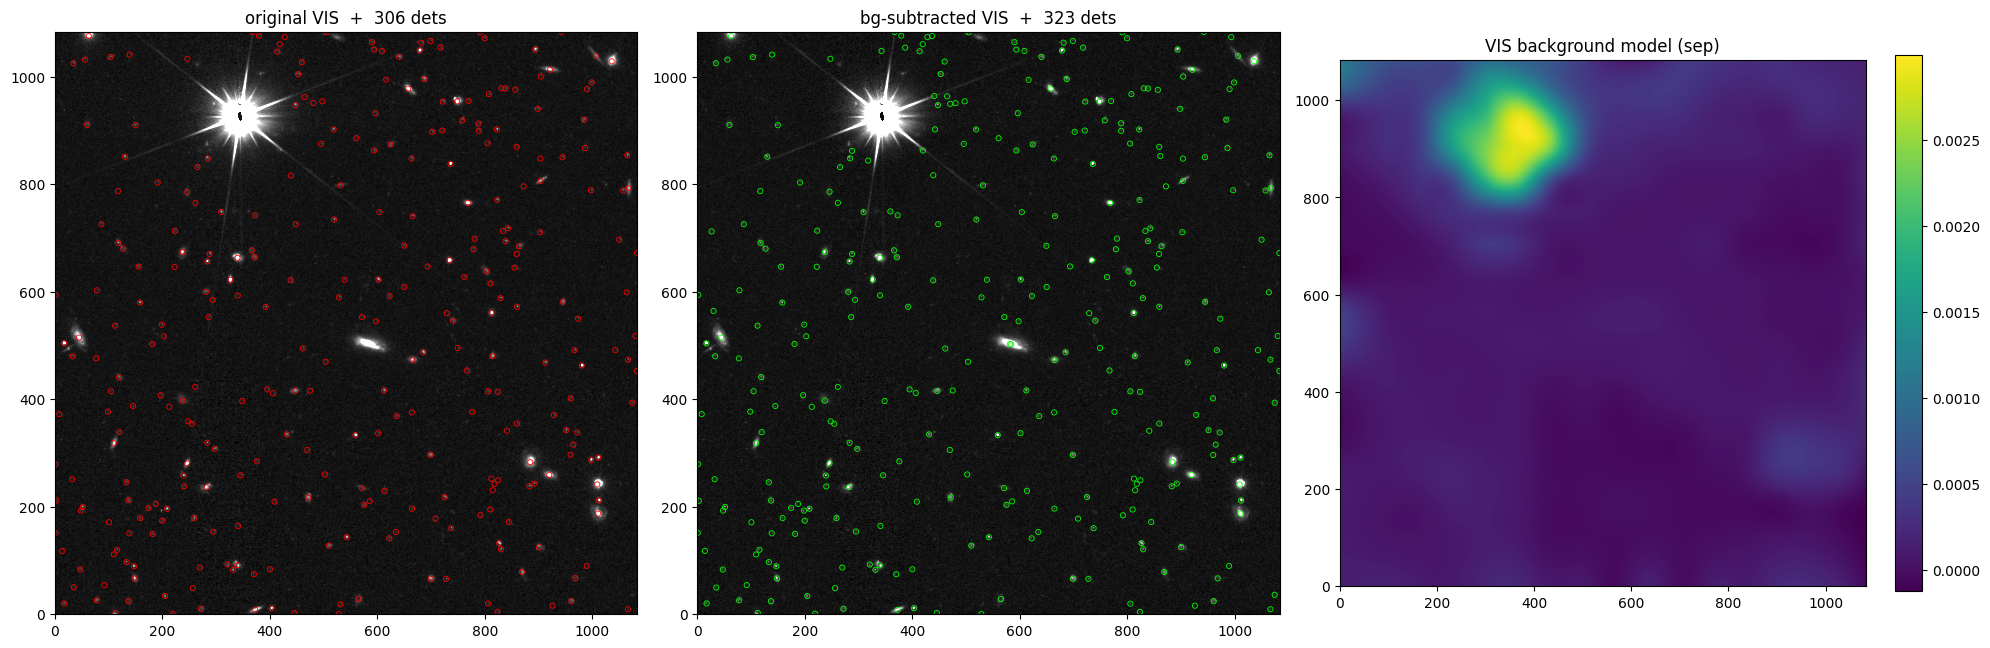

In [8]:
ed = np.load(EUCLID_DIR / f'{STEM}_euclid.npz', allow_pickle=True)
vis = np.nan_to_num(np.asarray(ed['img_VIS'], dtype=np.float32))
H, W = vis.shape
visbg = bg['euclid_VIS']
vissub = vis - visbg
vlo, vhi = zscale(vis)

fig, axs = plt.subplots(1, 3, figsize=(20, 6.8))
axs[0].imshow(vis, origin='lower', cmap='gray', vmin=vlo, vmax=vhi)
axs[0].scatter(xy0[:, 0] * W, xy0[:, 1] * H, s=14, facecolors='none', edgecolors='red', linewidths=0.6)
axs[0].set_title(f'original VIS  +  {len(xy0)} dets')
axs[1].imshow(vissub, origin='lower', cmap='gray', vmin=vlo, vmax=vhi)
axs[1].scatter(xy1[:, 0] * W, xy1[:, 1] * H, s=14, facecolors='none', edgecolors='lime', linewidths=0.6)
axs[1].set_title(f'bg-subtracted VIS  +  {len(xy1)} dets')
im = axs[2].imshow(visbg, origin='lower', cmap='viridis')
axs[2].set_title('VIS background model (sep)')
fig.colorbar(im, ax=axs[2], fraction=0.046)
for a in axs[:2]:
    a.set_xlim(0, W); a.set_ylim(0, H)
plt.tight_layout(); plt.show()

## Step 2 — Astrometry on EDF-S (joint canonical anchors)

The current production position instrument: CenterNet seeds → classical VIS refine → **joint multi-band canonical** position → per-band classical centroid → offset relative to the joint canonical. No neural head (the latent-head faint-end improvement was falsified); the foundation's OOD role here is the detection seeds. The per-band offset dispersion (band centroid vs the joint canonical) is the astrometric residual we compare to ECDFS.

**2026-06-24 (real var):** the EDF-S Euclid tiles now carry `var_*` maps, so `build_band_stack` and the exporter use real variance directly (the `_rms_from_var_or_image` MAD fallback only kicks in for NaN/no-coverage pixels). Switching from MAD-fallback to real var is a **re-weighting** of the joint-canonical fit: it pulls Rubin optical g/r/i/z *down* ~3–8 mas and lifts NISP ~4–9 mas. Net vs ECDFS (also real var), EDF-S is a uniform ~5–15% worse at matched SNR — the prior "NISP perfect / Rubin badly broken" split was largely the var fallback.

Export command (CPU multiprocessing; run once from repo root):

```bash
python models/astrometry2/export_joint_anchors.py \
    --rubin-dir       data/edf_s_ood/rubin_tiles_edfs \
    --euclid-dir      data/edf_s_ood/euclid_tiles_edfs \
    --detector-labels data/detection_labels/centernet_v10_edfs_thresh03.pt \
    --out             models/checkpoints/anchors_joint_canonical_edfs_var.npz \
    --workers 12
```

In [9]:
# Compare EDF-S (OOD) joint-canonical anchors vs ECDFS reference
# 2026-06-24: real-var re-run. EDF-S Euclid tiles now carry var_* maps (redownloaded from ESA),
# so this uses the real-variance anchors. MAD-fallback version kept at ..._edfs_MADvar_backup.npz.
EDFS_ANCH  = ROOT / 'models/checkpoints/anchors_joint_canonical_edfs_var.npz'
ECDFS_ANCH = ROOT / 'models/checkpoints/anchors_joint_canonical_790.npz'
BANDS = ['u', 'g', 'r', 'i', 'z', 'y', 'nisp_Y', 'nisp_J', 'nisp_H']
SNR_BINS = [(5, 7), (7, 10), (10, 15), (15, 30), (30, np.inf)]

def band_stats(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    per_band, all_off, all_snr = {}, [], []
    for b in BANDS:
        if f'{b}_raw' not in d:
            continue
        off = d[f'{b}_raw']; snr = d[f'{b}_snr']
        r = np.hypot(off[:, 0], off[:, 1]) * 1000.0  # mas
        per_band[b] = (np.median(r), len(r))
        all_off.append(r); all_snr.append(snr)
    all_off = np.concatenate(all_off); all_snr = np.concatenate(all_snr)
    by_snr = {}
    for lo, hi in SNR_BINS:
        m = (all_snr >= lo) & (all_snr < hi)
        by_snr[f'{lo}-{hi if np.isfinite(hi) else "inf"}'] = (np.median(all_off[m]) if m.any() else np.nan, int(m.sum()))
    return per_band, by_snr, (np.median(all_off), len(all_off))

ood_pb, ood_snr, ood_pool = band_stats(EDFS_ANCH)
ec_pb,  ec_snr,  ec_pool  = band_stats(ECDFS_ANCH)

print('per-band median offset (mas)   band-vs-joint-canonical')
print('%-9s %12s %12s' % ('band', 'EDF-S OOD', 'ECDFS'))
for b in BANDS:
    o = ood_pb.get(b); e = ec_pb.get(b)
    print('%-9s %7.1f (N%5d) %7.1f' % (b, o[0], o[1], e[0]) if o else '%-9s   (missing)' % b)
print('\npooled median: EDF-S %.1f mas (N=%d)   ECDFS %.1f mas (N=%d)' %
      (ood_pool[0], ood_pool[1], ec_pool[0], ec_pool[1]))
print('\nby SNR (pooled median mas):')
print('%-10s %14s %10s' % ('SNR', 'EDF-S OOD', 'ECDFS'))
for k in ood_snr:
    print('%-10s %7.1f (N%5d) %7.1f' % (k, ood_snr[k][0], ood_snr[k][1], ec_snr[k][0]))

per-band median offset (mas)   band-vs-joint-canonical
band         EDF-S OOD        ECDFS
u           126.9 (N 1537)   123.8
g            62.5 (N 4338)    47.0
r            47.4 (N 5232)    36.7
i            46.1 (N 4681)    33.1
z            57.2 (N 3689)    39.1
y            78.7 (N 2357)    81.1
nisp_Y       45.7 (N11657)    40.1
nisp_J       45.8 (N13214)    40.3
nisp_H       44.1 (N13028)    40.7

pooled median: EDF-S 48.9 mas (N=59733)   ECDFS 41.4 mas (N=707850)

by SNR (pooled median mas):
SNR             EDF-S OOD      ECDFS
5-7           73.1 (N18542)    63.1
7-10          54.6 (N14952)    48.2
10-15         42.2 (N13150)    37.3
15-30         26.4 (N11087)    22.5
30-inf         9.2 (N 2002)     8.4


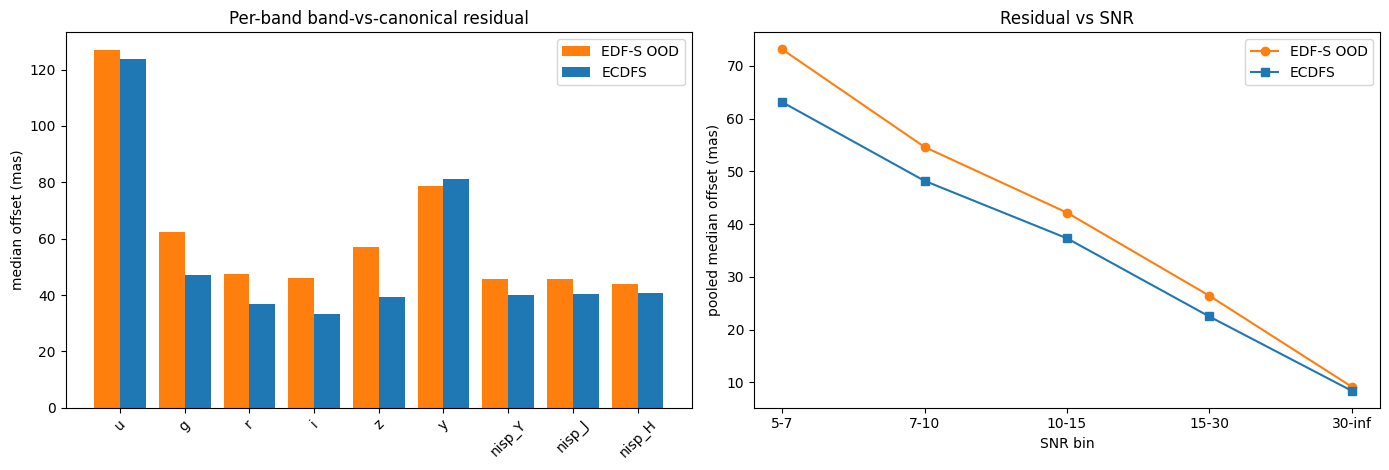

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(BANDS))
axs[0].bar(x - 0.2, [ood_pb[b][0] for b in BANDS], 0.4, label='EDF-S OOD', color='C1')
axs[0].bar(x + 0.2, [ec_pb[b][0] for b in BANDS], 0.4, label='ECDFS', color='C0')
axs[0].set_xticks(x); axs[0].set_xticklabels(BANDS, rotation=45)
axs[0].set_ylabel('median offset (mas)'); axs[0].set_title('Per-band band-vs-canonical residual'); axs[0].legend()

keys = list(ood_snr.keys())
xs = np.arange(len(keys))
axs[1].plot(xs, [ood_snr[k][0] for k in keys], 'o-', label='EDF-S OOD', color='C1')
axs[1].plot(xs, [ec_snr[k][0] for k in keys], 's-', label='ECDFS', color='C0')
axs[1].set_xticks(xs); axs[1].set_xticklabels(keys)
axs[1].set_xlabel('SNR bin'); axs[1].set_ylabel('pooled median offset (mas)')
axs[1].set_title('Residual vs SNR'); axs[1].legend()
plt.tight_layout(); plt.show()